## C. Clustering



## Import Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Read Data

In [3]:
df = pd.read_csv( 'df_EDA' )

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28356 entries, 0 to 28355
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  28356 non-null  object 
 1   track_popularity          28356 non-null  int64  
 2   playlist_genre            28356 non-null  object 
 3   danceability              28356 non-null  float64
 4   track_album_release_date  28356 non-null  object 
 5   tempo                     28356 non-null  float64
 6   energy                    28356 non-null  float64
 7   popularity_category       28356 non-null  object 
 8   release_year              28356 non-null  int64  
 9   bin_year                  28356 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 2.2+ MB


In [5]:
df_features = df[['danceability', 'tempo', 'energy']].copy()

## Cluster Analysis using KMeans

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


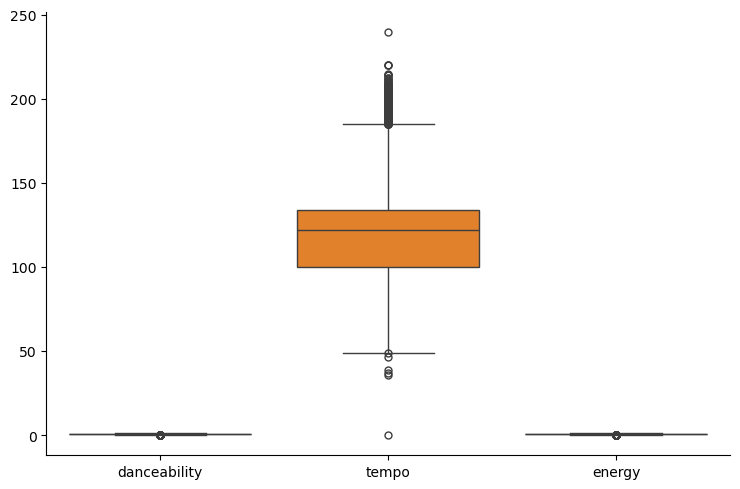

In [6]:
sns.catplot( data = df_features, kind='box', aspect=1.5)

plt.show()

#### Preprocess
Since the magnitud and scale is dominated by one variable we must STANDARDIZE.

In [7]:
dfx = StandardScaler().fit_transform( df_features )

In [8]:
dfx.shape

(28356, 3)

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


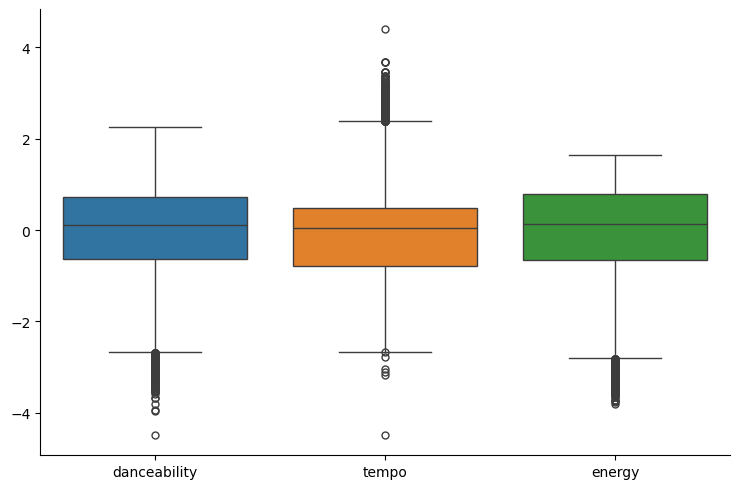

In [9]:
sns.catplot( data = pd.DataFrame( dfx, columns = df_features.columns), kind='box', aspect=1.5)

plt.show()

## Finding Optimal number of clusters

In [10]:
tots_within = []

K = range(1,31)

for k in K:
    km = KMeans(n_clusters=k, random_state=121, n_init=25, max_iter=500)
    km = km.fit(dfx)
    tots_within.append( km.inertia_ )
    

C:\Anaconda\envs\cmpinf2100\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Anaconda\envs\cmpinf2100\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Anaconda\envs\cmpinf2100\lib\subprocess.py", line 493, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Anaconda\envs\cmpinf2100\lib\subprocess.py", line 858, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Anaconda\envs\cmpinf2100\lib\subprocess.py", line 1327, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


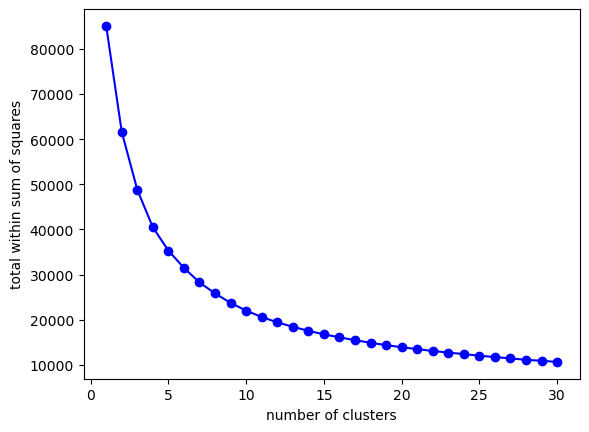

In [11]:
fig, ax = plt.subplots()

ax.plot( K, tots_within, 'bo-')
ax.set_xlabel('number of clusters')
ax.set_ylabel('total within sum of squares')

plt.show()

The WCSS curve flattens at k=3, meaning that adding more clusters doesn’t significantly improve cluster compactness. This suggests that 3 clusters provide a good balance between capturing variation in the data while avoiding overfitting.

## Using 3 clusters

In [12]:
clusters_3 = KMeans(n_clusters=3, random_state=121, n_init=25, max_iter=500).fit_predict(dfx)

In [13]:
df_features['k3'] = pd.Series( clusters_3, index=df_features.index).astype('category')

In [14]:
df['k3'] = pd.Series( clusters_3, index=df.index).astype('category')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28356 entries, 0 to 28355
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   track_id                  28356 non-null  object  
 1   track_popularity          28356 non-null  int64   
 2   playlist_genre            28356 non-null  object  
 3   danceability              28356 non-null  float64 
 4   track_album_release_date  28356 non-null  object  
 5   tempo                     28356 non-null  float64 
 6   energy                    28356 non-null  float64 
 7   popularity_category       28356 non-null  object  
 8   release_year              28356 non-null  int64   
 9   bin_year                  28356 non-null  object  
 10  k3                        28356 non-null  category
dtypes: category(1), float64(3), int64(2), object(5)
memory usage: 2.2+ MB


In [16]:
df.k3.value_counts()

k3
0    13064
2     8801
1     6491
Name: count, dtype: int64

Reshaping to long format.

In [17]:
df_melted = df_features.melt(id_vars=['k3'], value_vars=['danceability', 'tempo', 'energy'], 
                     var_name='Feature', value_name='Value')

In [18]:
# Adding Popularity_category to df_features
df_features['popularity_category'] = df.popularity_category

In [19]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28356 entries, 0 to 28355
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   danceability         28356 non-null  float64 
 1   tempo                28356 non-null  float64 
 2   energy               28356 non-null  float64 
 3   k3                   28356 non-null  category
 4   popularity_category  28356 non-null  object  
dtypes: category(1), float64(3), object(1)
memory usage: 914.0+ KB


## Comparing via pairplot the standardize features group by the `k3` (clusters) and `popularity_category`.

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


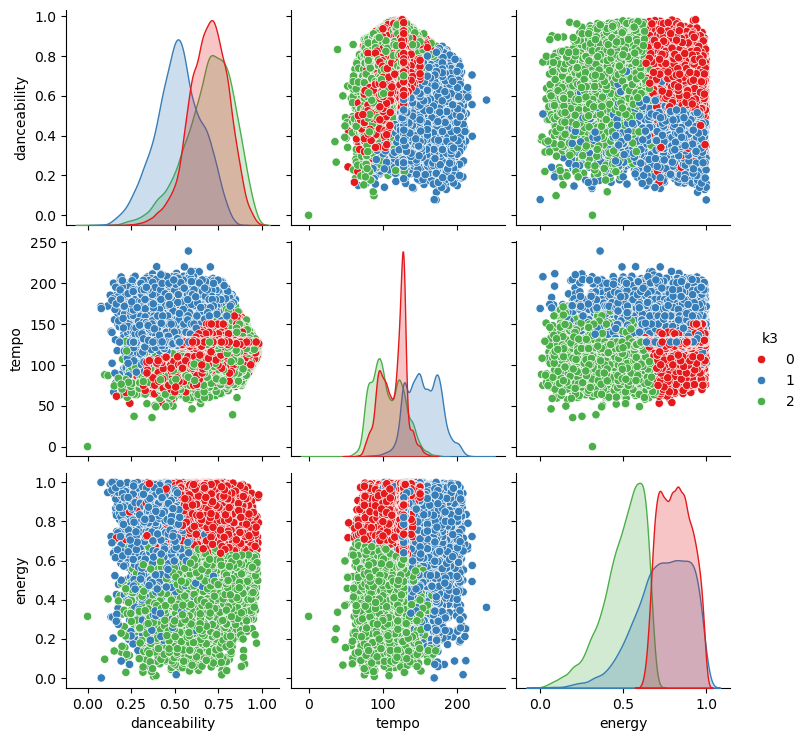

In [20]:
sns.pairplot( data = df_features, hue='k3', diag_kws={'common_norm': False}, palette='Set1')

plt.show()

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


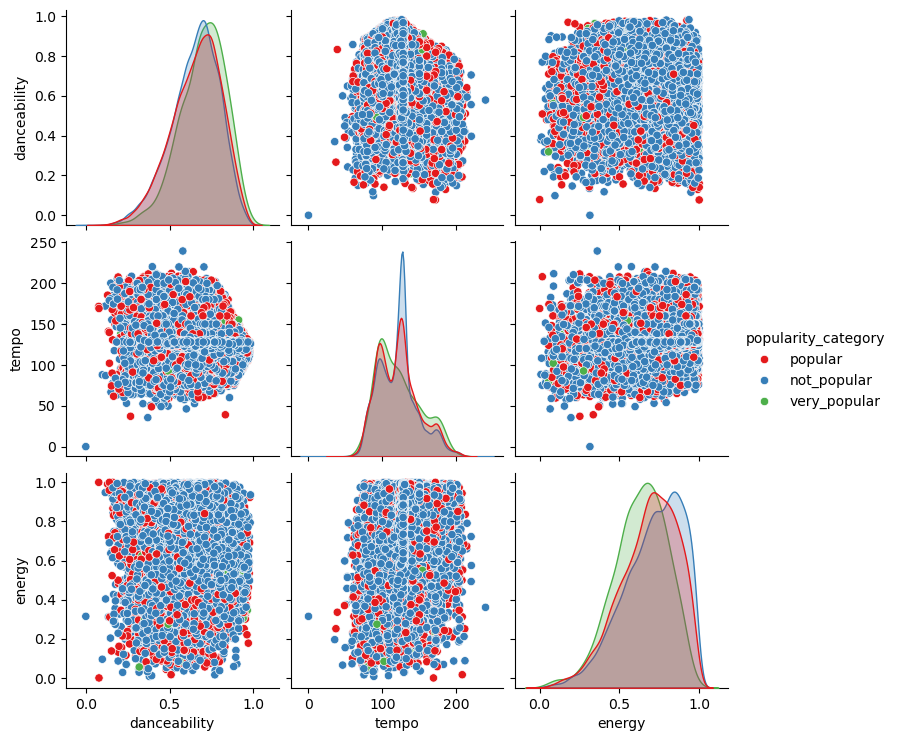

In [21]:
sns.pairplot(data = df.loc[ :, ['danceability', 'tempo', 'energy', 'popularity_category']],
             hue='popularity_category', diag_kind='kde',  diag_kws={'common_norm': False}, 
             palette='Set1')

plt.show()

The color by `k3` pairplot found that might not align perfectly with popularity, but show useful feature groupings.

The color by `popularity_category` exposes the overlap and ambiguity of the popularity label — a reminder that classification based on audio features alone may require richer feature engineering or more sophisticated models.

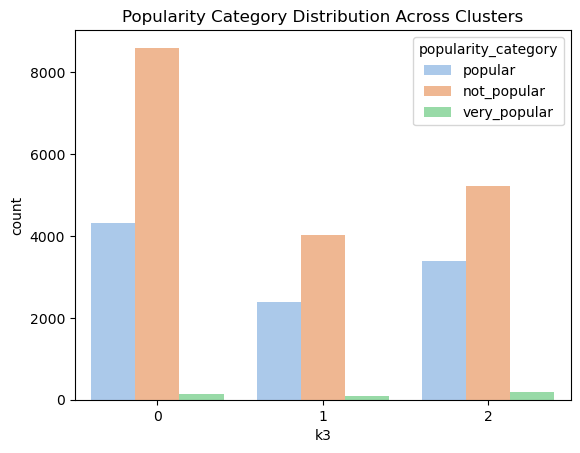

In [22]:
sns.countplot(data=df_features, x='k3', hue='popularity_category', palette='pastel')
plt.title("Popularity Category Distribution Across Clusters")

plt.show()

The clustering is based on danceability, tempo, and energy, but most songs in each cluster are still ‘not_popular’. This suggests that these features alone don’t strongly determine popularity.

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


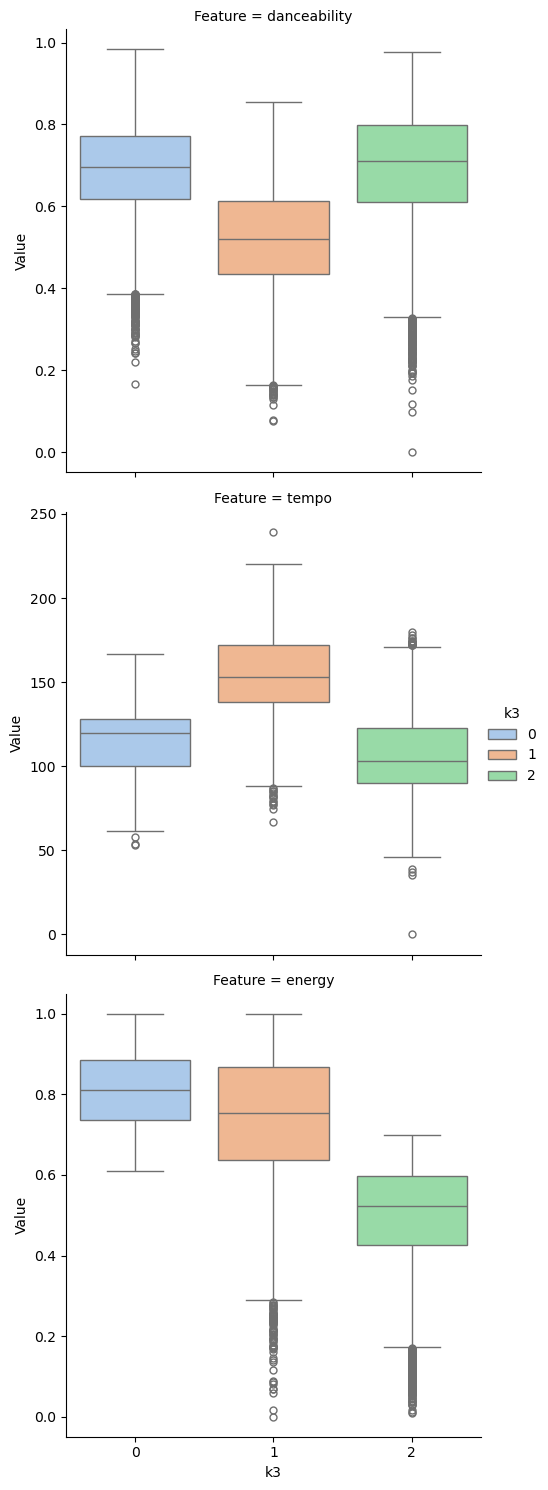

In [23]:
sns.catplot(data=df_melted, x='k3', y='Value', hue='k3', row='Feature', palette='pastel', sharey=False, kind='box')

plt.show()

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


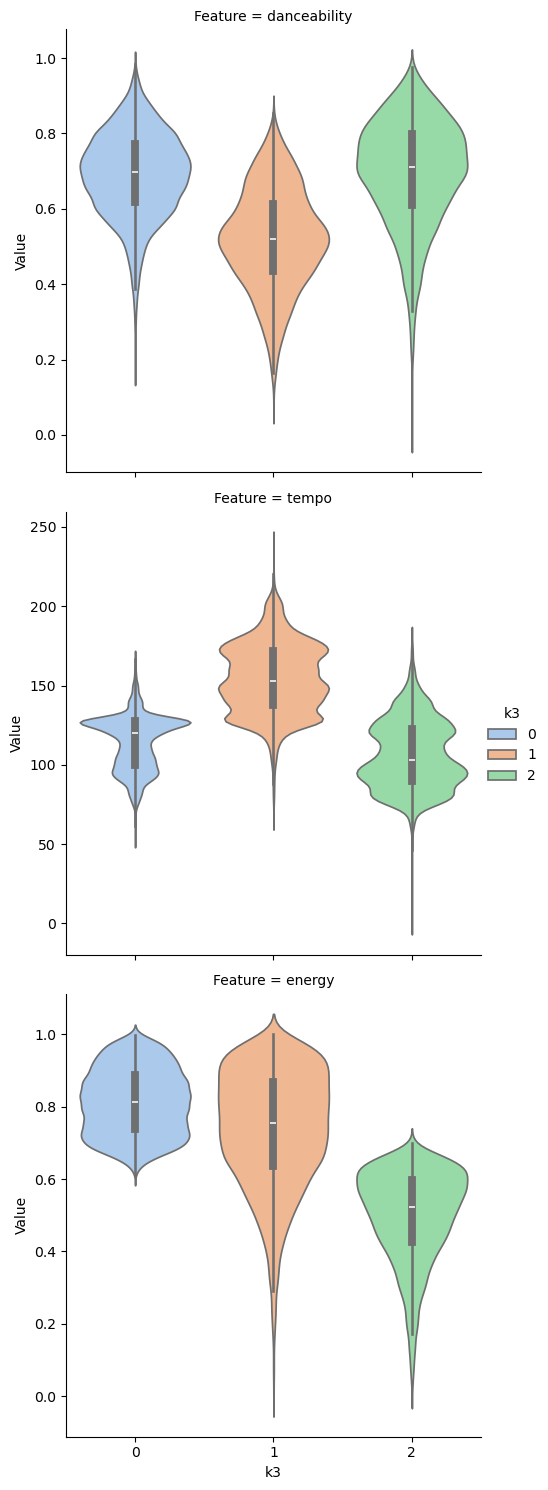

In [24]:
sns.catplot(data=df_melted, x='k3', y='Value', hue='k3', row='Feature', palette='pastel', sharey=False, kind='violin')

plt.show()

#### Overall Insights for boxplots and violin plots:
- Clusters 0 and 2 appear to be composed of more danceable and lower-energy songs, while Cluster 1 is characterized by higher `tempo` and higher `energy`.

- The presence of outliers in clusters 1 and 2 indicates that there are some songs that are extreme in terms of `tempo` or `energy`, which may represent songs from genres that don't fit neatly into the typical characteristics of the cluster.

- `Tempo` shows a non-Gaussian distribution, meaning that songs within each cluster span a wider range of tempos, not just one central value. This suggests that the `tempo` feature alone might not be enough to differentiate the clusters perfectly.

- `Energy` and `danceability` tend to follow Gaussian distributions, which suggests that most songs within each cluster have a relatively consistent level of `energy` and `danceability`.



## Relationship between 3 variables using 3 clusters group by the response variable

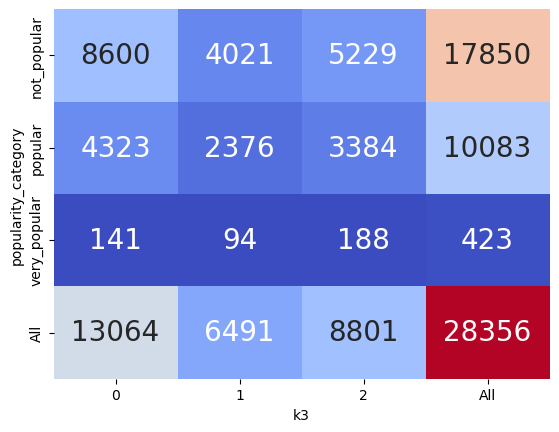

In [25]:
fig, ax = plt.subplots()

sns.heatmap( data = pd.crosstab( df.popularity_category, df.k3, margins=True),
            annot=True, annot_kws={"fontsize":20}, fmt='g',
            cmap='coolwarm', cbar=False, ax=ax)

plt.show()

This table shows the count of songs in each popularity category within each cluster:

not_popular songs dominate all clusters, especially in Cluster 0.

popular and very_popular songs are more prevalent in Cluster 2.

While the majority of songs are still not_popular, there's a trend where popular and very_popular songs tend to fall into specific clusters, indicating that popularity may correlate with combinations of `danceability`, `tempo`, and `energy`.

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


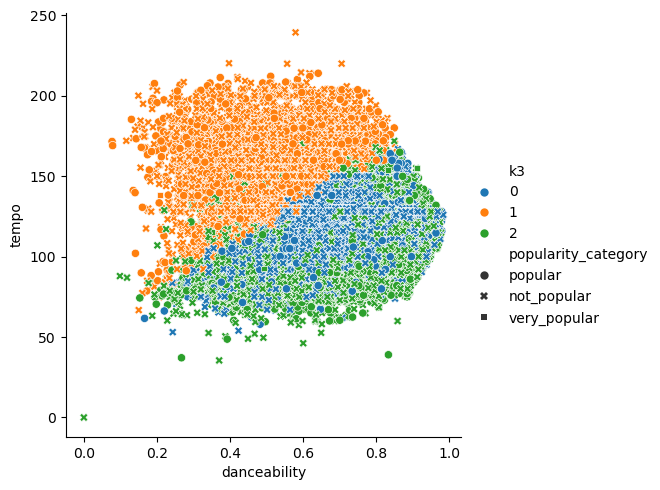

In [26]:
sns.relplot(data = df, x='danceability', y='tempo', hue='k3', style='popularity_category')

plt.show()

This plot shows how songs are clustered in a 2D space using features like `danceability` and `tempo`, with point color representing popularity category.

There's noticeable overlap between popularity classes, but some areas are more densely populated with popular or very_popular songs, reinforcing the idea that musical characteristics influence popularity.

## PCA to support cluster analysis

In [27]:
from sklearn.decomposition import PCA

In [28]:
pca_df = PCA(n_components=3).fit_transform(dfx)

In [29]:
pca_df1 = pd.DataFrame(pca_df, columns=['pc01', 'pc02', 'pc03'])

In [30]:
pca_df1['k3'] = pd.Series(clusters_3, index=pca_df1.index).astype('category')

In [31]:
pca_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28356 entries, 0 to 28355
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   pc01    28356 non-null  float64 
 1   pc02    28356 non-null  float64 
 2   pc03    28356 non-null  float64 
 3   k3      28356 non-null  category
dtypes: category(1), float64(3)
memory usage: 692.5 KB


C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


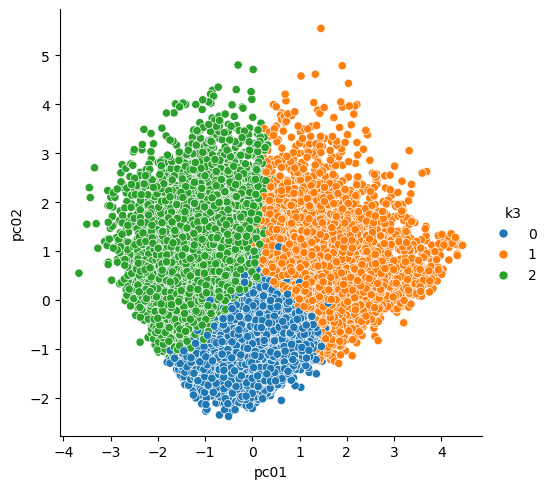

In [32]:
sns.relplot(data=pca_df1, x='pc01', y='pc02', hue='k3')

plt.show()

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


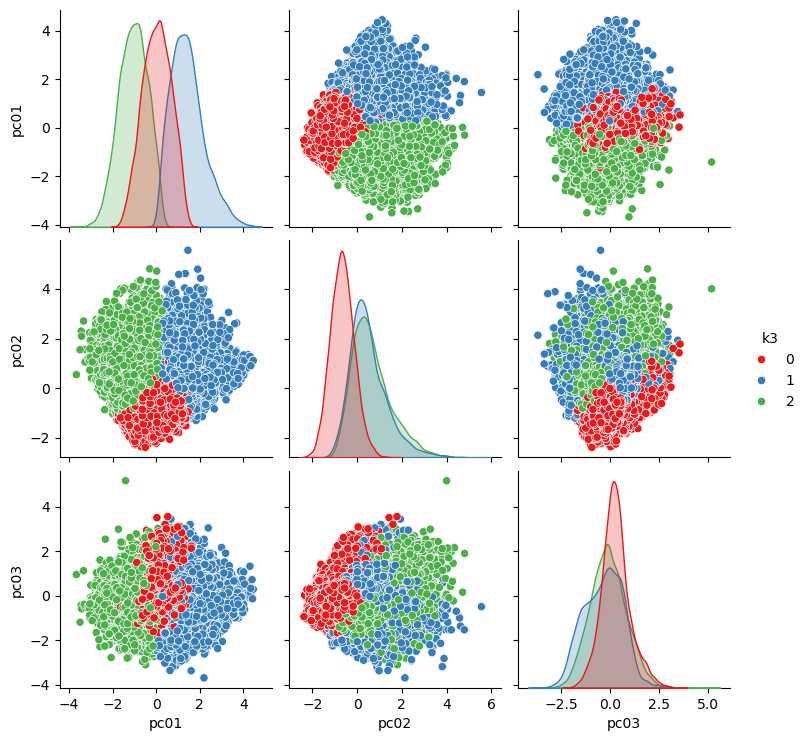

In [33]:
sns.pairplot( data = pca_df1, hue='k3', diag_kws={'common_norm': False}, palette='Set1')

plt.show()

This pairplot shows that:

Very popular songs tend to have higher `energy` and more consistent `tempo`.

Not popular songs are spread more widely across feature values, reflecting greater variability or randomness in their characteristics.



In [34]:
from sklearn.preprocessing import LabelEncoder

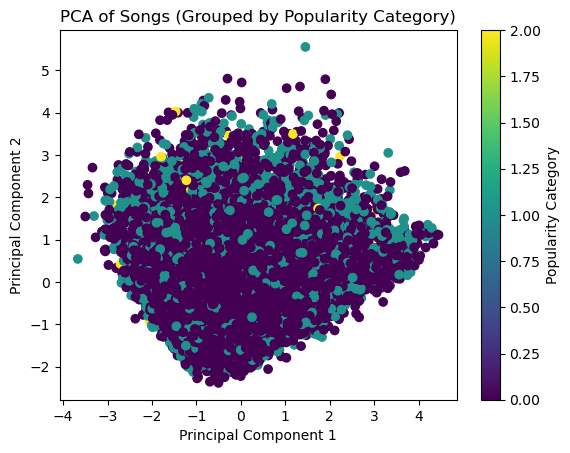

In [35]:
df_copy = df.copy()
label_encoder = LabelEncoder()
df_copy['popularity_category_encoded'] = label_encoder.fit_transform(df_copy['popularity_category'])

# Plot PCA results, coloring by encoded popularity category
plt.scatter(pca_df[:, 0], pca_df[:, 1], c=df_copy['popularity_category_encoded'], cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Songs (Grouped by Popularity Category)')
plt.colorbar(label='Popularity Category')  # Add colorbar to show the mapping
plt.show()

The PCA projection shows a 2D embedding of the songs using principal components of the feature set.

Despite some overlap, clustered regions are visible, and the distribution reflects underlying structure in the feature space that partially corresponds to popularity categories.